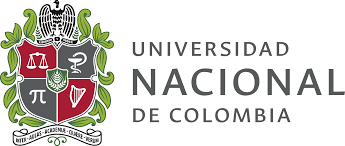

 Facultad de Ciencias.\
 Departamento de Estadística.\
 Carrera de Estadística\
 Profesor: Campo Elias Pardo



<FONT FACE="cambria" SIZE=6 COLOR="green">
Juan Pablo Torres, John Moyano, Camilo Alarcón.
</FONT> 










# Minería de Textos.
La minería de textos busca extraer información útil e importante de formatos de documentos heterogéneos, tales como páginas web, correos electrónicos, medios sociales, artículos de revistas, etc. Esto se hace mediante la identificación de patrones dentro de los textos, tales como tendencias en el uso de palabras, frecuencias, etc.


![imagen1](http://2.bp.blogspot.com/-sAy2ZhBb0wM/UgRHbLG7syI/AAAAAAAAAPM/o4G2c4TuKus/s320/textmining.png)



<FONT FACE="cambria" SIZE=6 COLOR="red">
Bases:
</FONT>

In [ ]:
library(stringr)
library(lubridate)

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Concatenar caracteres:</FONT>


In [ ]:
str_c("hola", "mundo", sep=" ")
#objeto tipo caracter

[1] "hola mundo"

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Contar caracteres </FONT>

In [ ]:
str_length("hola mundo")
str_length(c("hola", "mundo"))

[1] 10

[1] 4 5

<FONT FACE="cambria" SIZE=6 COLOR="red">
Normalizar texto 
</FONT>

La normalización de texto es el proceso de transformación de texto para la obtención de una forma canónica.

En español y otros idiomas tambien se tienen en cuenta los acentos, lo que se suele hacer es deshacerse de las tildes. 

Se sabe que en el español hay palabras que con o sin tilde significan cosas diferentes pero la gran mayoria de estas palabras son stopwords (palabras que no aportan al análisis)

También depende del análisis, si usted ve que puede afectarle el hecho de dejar acento debe dejarla.

Antes de hacer cualquier análisis normalice las variables

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Mayúsculas a minúsculas </FONT>

In [ ]:
toupper("Manipulación de Texto")

tolower("Manipulación de Texto")

[1] "MANIPULACIÓN DE TEXTO"

[1] "manipulación de texto"

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Manipulación de texto </FONT>

In [ ]:

s="Manipulación de Texto"

str_sub(s,start=3,end=6)
#el texto empieza en la tercera posicion y termina en la sexta

[1] "nipu"

In [ ]:
str_sub(s,1,-8)
#puede ir de derecha a izquierda

[1] "Manipulación d"

In [ ]:
str_sub(s,1,-8)<-"le"
s
#reemplazar el texto sustraido 

[1] "lee Texto"

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Espacio en blanco </FONT>

Nunca se debe empezar un analisis sin saber que ocurre con el espacio en blanco, visualmente la palabra puede verse igual pero el computador no lo reconoce así

In [ ]:
EB=c(" abc","def "," ghi ","hola mundo")

str_trim(EB)

[1] "abc"        "def"        "ghi"        "hola mundo"

In [ ]:
str_trim(EB,side="left") #right, both

[1] "abc"        "def "       "ghi "       "hola mundo"

In [ ]:
str_pad("abc",width=7,side="left")
#Rellenar con espacios en blanco

[1] "    abc"

In [ ]:
str_pad("abc",width=7,side="left",pad="@")

[1] "@@@@abc"

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Seleccionar palabras </FONT>

In [ ]:
st=c("muchas palabras escritas","el pasto es verde")

word(st,start=1,end=2)

[1] "muchas palabras" "el pasto"

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Patrones </FONT>

Aprender a manejar caracteres especiales, manejar espacios, sustituciones y transformaciones

In [ ]:
s=c("hands","data","on","data$cience","handsonddata$cience","handson")

grep(pattern="^data",s,value=TRUE)
#^data  significa identifique los patrones cuya primera componente sea "data"

[1] "data"        "data$cience"

In [ ]:
grep(pattern="on$",s, value=TRUE)
#on$  significa identifique los patrones cuya ultima componente sea "on"

[1] "on"      "handson"

In [ ]:
grep(pattern="\\$",s, value=TRUE)
# \\ en alguna parte de la palabra

[1] "data$cience"         "handsonddata$cience"

In [ ]:
s=c("abc12","@#$","345","ABcd")

grep(pattern = "[0-9]",s,value=TRUE) #identificar los elementos que tienen números


[1] "abc12" "345"

In [ ]:
grep(pattern = "[A-Z]",s,value=TRUE) #identificar los que tengan alguna mayuscula

[1] "ABcd"

In [ ]:
grep(pattern = "[[:alpha:]]",s,value=TRUE) #Identificar caracteres

[1] "abc12" "ABcd"

<FONT FACE="cambria" SIZE=5 COLOR="red">
Ejemplo: </FONT>

Veamos un ejemplo muy introductorio de como analizar texto (en este caso twitts)
Trabajaremos con la base oct_delta. Esta base contiene twitts del servicio al cliente de la aerolinea Delta Airlines

La idea es obtener información a partir de los textos para responder alguna pregunta de interés
la idea con esta base de datos es ayudarle a ver al servicio al cliente cuales son los patrones en los twitts 

1. ¿Cuál es la media de respuesta de un agente a un cliente
2. ¿Cuáles son los links más referenciados?
3. ¿Cuántas respuestas son razonables para que las maneje un representante de servicio al cliente?
4. Ver patrones en los comentarios

In [ ]:
library(readxl)
text.df=read_excel("/content/oct_delta.xlsx") #importamos la base

In [ ]:
text.df <- text.df[!is.na(text.df$text),] #retiramos textos con NA
head(text.df)

weekday,month,date,year,text
<chr>,<chr>,<dbl>,<dbl>,<chr>
Thu,Oct,1,2015,@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. Thanks for your patience. *AA
Thu,Oct,1,2015,"@rmarkerm Terribly sorry for the inconvenience. If we can be of assistance at this time, pls let us know. *AA"
Thu,Oct,1,2015,"@checho85 I can check, pls follow and DM your confirmation # for review. *AA"
Thu,Oct,1,2015,"@nealaa ...Alerts, pls check here: http://t.co/0jlcZnT95Q *JH 3/3"
Thu,Oct,1,2015,"@nealaa ...advisory has only been issued for the Bahamas, but that could change. To check for updates on Weather advisories &amp"
Thu,Oct,1,2015,@nealaa Hi. Our meteorologist team is aware of Hurricane Joaquin &amp


In [ ]:
dim(text.df)

[1] 1377    5

In [ ]:
class(text.df$text)

[1] "character"

<FONT FACE="cambria" SIZE=6 COLOR="blue">
Iniciamos viendo las estadísticas básicas de los tweets </FONT>

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Número de caracteres </FONT>

In [ ]:
nchar(head(text.df$text))

[1] 119 110  78  65 129  69

<FONT FACE="cambria" SIZE=5 COLOR="blue">
promedio de caracteres en los tweets </FONT>

In [ ]:
mean(nchar(text.df$text))

[1] 89.42556

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Sustituir texto </FONT>

In [ ]:
text.df[1,5]
sub("thanks", "thank you", text.df[1,5],ignore.case = T)
#hace remplazo solo la primera vez que lo encuentra (ignorando si es mayúscula o minúscula)

text
<chr>
@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. Thanks for your patience. *AA


[1] "@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. thank you for your patience.  *AA"

In [ ]:
text.df[2,5]
sub("pls","please",text.df[2,5],ignore.case = T)

text
<chr>
"@rmarkerm Terribly sorry for the inconvenience. If we can be of assistance at this time, pls let us know. *AA"


[1] "@rmarkerm Terribly sorry for the inconvenience. If we can be of assistance at this time, please let us know.  *AA"

In [ ]:
gsub("thanks", "thank you", text.df[1,5],ignore.case = T)
#hace remplazo en toda la instancia

[1] "@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. thank you for your patience.  *AA"

In [ ]:
text.df[5,5]
gsub("&amp","",text.df[5,5])
#Si quiere eliminar la palabra, remplacela por nada

text
<chr>
"@nealaa ...advisory has only been issued for the Bahamas, but that could change. To check for updates on Weather advisories &amp"


[1] "@nealaa ...advisory has only been issued for the Bahamas, but that could change.  To check for updates on Weather advisories "

In [ ]:
text.df[1,5]
gsub("[[:punct:]]","",text.df[1,5])
#retirar los signos de puntuacion y caracteres especiales


text
<chr>
@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. Thanks for your patience. *AA


[1] "mjdout I know that can be frustratingwe hope to have you parked and deplaned shortly Thanks for your patience  AA"

In [ ]:
#pequeño ejemplo de sustitución
text.df[1,]
patterns<-c("Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec")
replacements<-seq(1:12)

#Remplazamos el mes por el número del mes
for (i in 1:12) {
  text.df$month=gsub(patterns[i],replacements[i],text.df$month)
}

text.df$combined<-paste(text.df$month,text.df$date,text.df$year,sep = "-")
#crear nueva variable con fecha completa

text.df$combined<-mdy(text.df$combined)
text.df[1,]

weekday,month,date,year,text
<chr>,<chr>,<dbl>,<dbl>,<chr>
Thu,Oct,1,2015,@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. Thanks for your patience. *AA


weekday,month,date,year,text,combined
<chr>,<chr>,<dbl>,<dbl>,<chr>,<date>
Thu,10,1,2015,@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. Thanks for your patience. *AA,2015-10-01


<FONT FACE="cambria" SIZE=5 COLOR="blue">
Veamos características de los tweets teniendo en cuenta algunas fechas específicas </FONT>

In [ ]:
agentes<-strsplit(text.df$text,"[*]")
#dividir en lista segun caracter
#crea una lista con las divisiones
agentes[1]

[[1]]
[1] "@mjdout I know that can be frustrating..we hope to have you parked and deplaned shortly. Thanks for your patience.  "
[2] "AA"

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Identificar los agentes más y menos activos entre el 5 de octubre y el 9 de octubre </FONT>

In [ ]:
last.chars<-function(text,num) substr(text,nchar(text)-num+1,nchar(text))
#Creamos una función para identificar los ultimos caracteres en el texto
#lo hacemos para identificar los agentes asociados con el tweet
weekdays=subset(text.df,text.df$combined>=mdy("10- 05-2015")& text.df$combined <=mdy("10- 09-2015"))
#filtro de datos por fecha (fechas mayores a 5 de oct y menores a 9 de oct)
#Aquí vemos una de las ventajas de lubridate
table((last.chars(weekdays$text,2)))


/2 /3 /4 AA AD AN BB CK CM DD DR EC ht HW JH JJ KC KM LS MD ML mp MR NG PL QB 
89 11  8 32  7  6 14  7  4 15  5  6  1  5  5  1  8  1 12  6 10 23 15 31 14  3 
RD RS SB SD TP VI VM WG 
25 14 17 14  6  8  6 31 

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Porcentaje de tweets donde aparece la palabra sorry </FONT>

In [ ]:
grep("sorry",text.df$text,ignore.case = T)
# identificar los tweets donde el operador escribio sorry


[1]    2   18   22   26   29   37   40   44   47   50   65   71   84  103  107
 [16]  108  110  111  120  122  127  136  138  143  153  164  174  178  186  188
 [31]  201  210  216  228  236  238  256  260  263  264  265  268  280  288  290
 [46]  301  316  318  320  326  343  348  353  354  364  369  376  382  386  405
 [61]  413  416  422  426  427  431  432  433  460  464  487  504  511  513  515
 [76]  524  533  553  556  576  578  610  614  623  636  652  653  676  682  691
 [91]  693  695  701  705  711  714  733  734  737  739  741  758  773  782  791
[106]  795  825  830  834  837  838  839  846  852  856  863  868  872  880  881
[121]  883  885  891  907  926  931  934  938  949  952  964  968  993  996 1008
[136] 1009 1013 1014 1016 1017 1023 1027 1062 1080 1083 1084 1094 1098 1100 1103
[151] 1106 1109 1114 1143 1144 1149 1151 1155 1157 1181 1200 1205 1207 1220 1227
[166] 1252 1259 1260 1262 1268 1273 1288 1298 1321 1328 1340 1366 1369

In [ ]:
sorry=grepl("sorry",text.df$text, ignore.case = T)
#grep pero da falsos y verdaderos

sum(sorry)/nrow(text.df)

[1] 0.1292665

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Porcentaje de tweets donde aparece la palabra sorry y apologize </FONT>

In [ ]:
sorry=grepl(c("sorry|apologize"),text.df$text,ignore.case=T)
sum(sorry)/nrow(text.df)

[1] 0.1503268

<FONT FACE="cambria" SIZE=7 COLOR="red">
Minería de textos </FONT>

<FONT FACE="cambria" SIZE=6 COLOR="blue">
Trabajaremos con la librería tidytext </FONT>

Corpus: Conjunto cerrado de textos con el cual se hará el análisis.

In [ ]:
#Librerias
install.packages("tidytext")
library(tidytext)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘SnowballC’, ‘hunspell’, ‘janeaustenr’, ‘tokenizers’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
text<- c("Because i could not stop for Death -",
           "He kindly stopped for me -",
           "The Carriage held buy Ourselves -",
           "and Inmortality")
#convertir a data frame
text_df=data_frame(line=1:4,text=text)
class(text_df)
text_df

Warning message:
“`data_frame()` was deprecated in tibble 1.1.0.
Please use `tibble()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated.”


[1] "tbl_df"     "tbl"        "data.frame"

line,text
<int>,<chr>
1,Because i could not stop for Death -
2,He kindly stopped for me -
3,The Carriage held buy Ourselves -
4,and Inmortality


<FONT FACE="cambria" SIZE=6 COLOR="blue">
Tokenización </FONT>

<FONT FACE="cambria" SIZE=5 COLOR="black">
Tokenizacion es el proceso de dividir un texto en tokens </FONT>

<FONT FACE="cambria" SIZE=5 COLOR="black">
Token es la unidad de analisis con la que se quiere trabajar (se busca trabajar con palabras o ngramas -redes de palabras-).

Inicialmente trabajaremos con tokens de palabras. </FONT>

In [ ]:
head(text_df %>% unnest_tokens(tbl=.,output = word,input=text),10)

line,word
<int>,<chr>
1,because
1,i
1,could
1,not
1,stop
1,for
1,death
2,he
2,kindly


Quedan 2 columnas, la primera es la linea donde está el token y la segunda el token.

Automáticamente pasó a minúscula las palabras y retiró caracteres especiales

Normalizó las palabras.

<FONT FACE="cambria" SIZE=5 COLOR="red">
Ejemplo: </FONT>

Vamos a trabajar con un corpus de 6 novelas de Jane Austen
- Sense and Sensibility 
- Pride and prejudice
- Mansfield Park
- Emma
- Northanger Abbey
- Persuasion

In [ ]:
#Librerias
library(tidytext)
library(janeaustenr)
library(stringr)
library(dplyr)
library(ggplot2)

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Veamos los datos </FONT>

In [ ]:
austen_books()

,text,book
,<chr>,<fct>
1,SENSE AND SENSIBILITY,Sense & Sensibility
2,,Sense & Sensibility
3,by Jane Austen,Sense & Sensibility
4,,Sense & Sensibility
5,(1811),Sense & Sensibility
6,,Sense & Sensibility
7,,Sense & Sensibility
8,,Sense & Sensibility
9,,Sense & Sensibility


<FONT FACE="cambria" SIZE=5 COLOR="blue">
Agrupamos por libro y creamos dos variables nuevas </FONT>

In [ ]:
original_books<-austen_books()%>%
          group_by(book)%>%
          mutate(linenumber = row_number(),
              chapter=cumsum(str_detect(string=text,pattern=regex("^chapter [\\divxlc]",ignore_case = TRUE)))) %>%
          ungroup()

In [ ]:
original_books

text,book,linenumber,chapter
<chr>,<fct>,<int>,<int>
SENSE AND SENSIBILITY,Sense & Sensibility,1,0
,Sense & Sensibility,2,0
by Jane Austen,Sense & Sensibility,3,0
,Sense & Sensibility,4,0
(1811),Sense & Sensibility,5,0
,Sense & Sensibility,6,0
,Sense & Sensibility,7,0
,Sense & Sensibility,8,0
,Sense & Sensibility,9,0


<FONT FACE="cambria" SIZE=5 COLOR="blue">
Tokenización (una palabra por fila)</FONT>

In [ ]:
tidy_books=original_books%>%
      unnest_tokens(tbl= .,output = word,input=text)
tidy_books

book,linenumber,chapter,word
<fct>,<int>,<int>,<chr>
Sense & Sensibility,1,0,sense
Sense & Sensibility,1,0,and
Sense & Sensibility,1,0,sensibility
Sense & Sensibility,3,0,by
Sense & Sensibility,3,0,jane
Sense & Sensibility,3,0,austen
Sense & Sensibility,5,0,1811
Sense & Sensibility,10,1,chapter
Sense & Sensibility,10,1,1


<FONT FACE="cambria" SIZE=6 COLOR="blue">
Stop words</FONT>

Stop words es el nombre que reciben las palabras sin significado como artículos, pronombres, preposiciones. Son filtradas antes o después del procesamiento de datos porque no aportan información al mismo.

In [ ]:
data(stop_words)
stop_words
#tidytext tiene 3 diccionarios con las stopwords
table(stop_words$lexicon)
##se le pueden agregar palabras

word,lexicon
<chr>,<chr>
a,SMART
a's,SMART
able,SMART
about,SMART
above,SMART
according,SMART
accordingly,SMART
across,SMART
actually,SMART



    onix    SMART snowball 
     404      571      174 

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Remover stop words</FONT>

In [ ]:
tidy_books=tidy_books%>% 
      anti_join(x= .,y=stop_words)
tidy_books
#de 725000 palabras pasamos a 217000 notese el importante corte de palabras

Joining, by = "word"



book,linenumber,chapter,word
<fct>,<int>,<int>,<chr>
Sense & Sensibility,1,0,sense
Sense & Sensibility,1,0,sensibility
Sense & Sensibility,3,0,jane
Sense & Sensibility,3,0,austen
Sense & Sensibility,5,0,1811
Sense & Sensibility,10,1,chapter
Sense & Sensibility,10,1,1
Sense & Sensibility,13,1,family
Sense & Sensibility,13,1,dashwood


<FONT FACE="cambria" SIZE=6 COLOR="blue">
Importancia de palabras
</FONT>

In [ ]:
##contar palabras
head(tidy_books %>% count(word,sort=TRUE),10)

word,n
<chr>,<int>
miss,1855
time,1337
fanny,862
dear,822
lady,817
sir,806
day,797
emma,787
sister,727


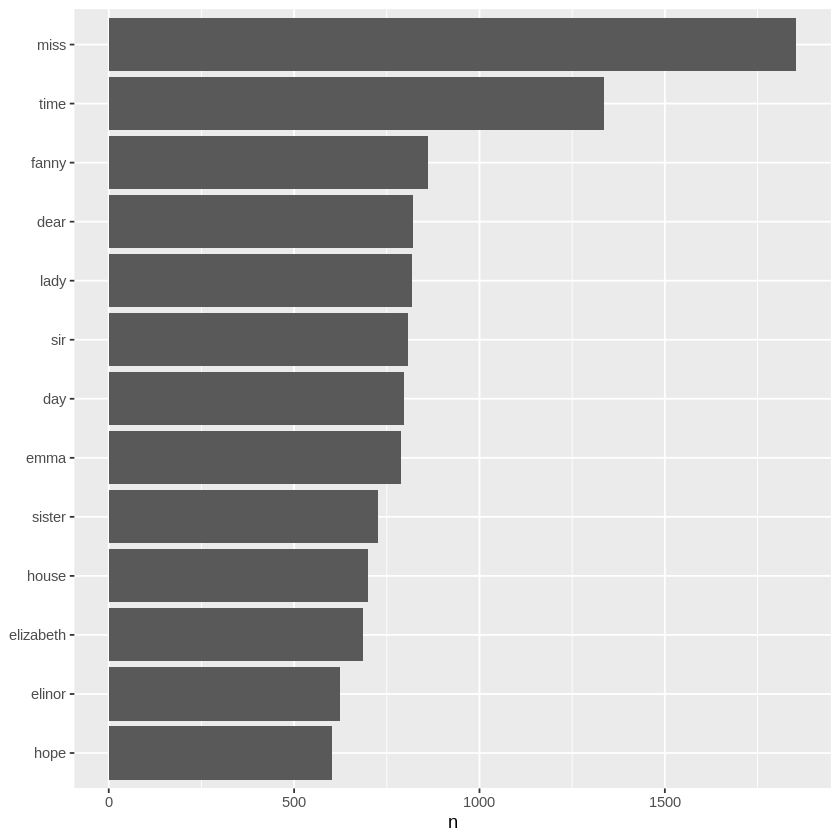

In [ ]:
##Visualización
tidy_books %>%
        count(word,sort=TRUE)%>%
        filter(n>600)%>%
        mutate(word=reorder(word,n)) %>%
        ggplot(aes(word,n))+
        geom_col()+
        xlab(NULL)+
        coord_flip()

##Frecuencias absolutas de las palabras

<FONT FACE="cambria" SIZE=6 COLOR="red">
Análisis de Sentimiento 
</FONT>

Cuando los lectores humanos se acercan a un texto, utilizamos nuestra comprensión de la **intención emocional** de las palabras para inferir si una sección del texto es positiva o negativa, o tal vez se caracteriza por alguna otra emoción más matizada como sorpresa o disgusto. 

Una forma de analizar el sentimiento de un texto es considerar el texto como una **combinación de sus palabras individuales** y el contenido de sentimiento de todo el texto como la suma del contenido de sentimiento de las palabras individuales. Esta no es la única forma de abordar el análisis de sentimientos, pero es un enfoque de uso frecuente. 

Como se mencionó anteriormente, existe una variedad de **métodos y diccionarios** para evaluar la opinión o la emoción en un texto. El paquete tidytext proporciona acceso a varios **léxicos de sentimientos**.

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Los conjuntos de datos de «sentimientos»
</FONT>

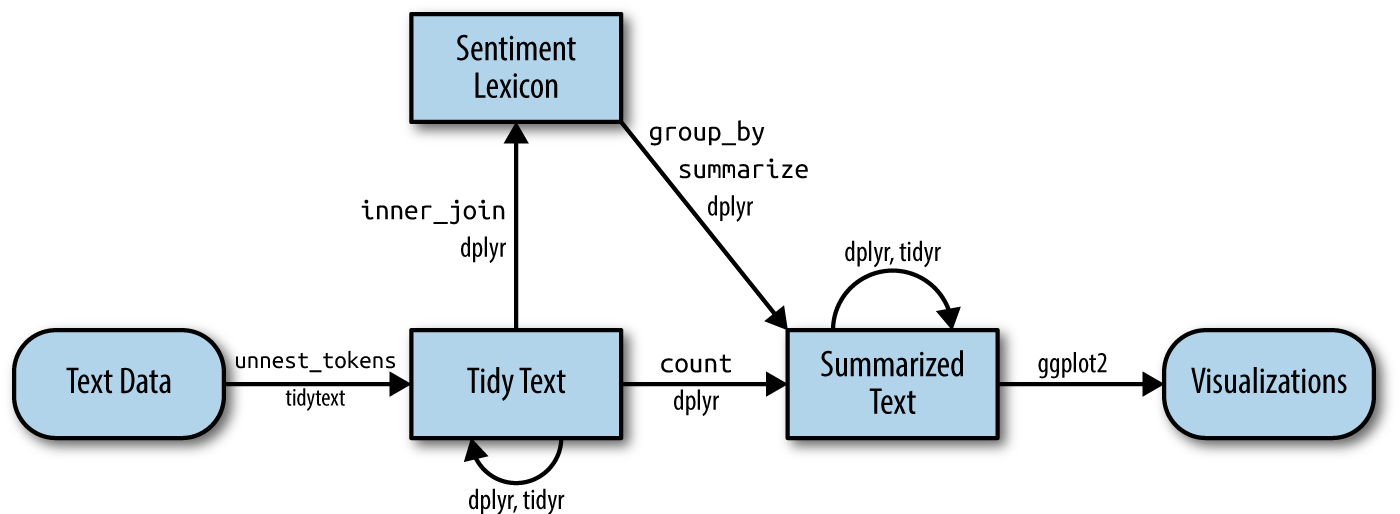

Como se mencionó anteriormente, existe una variedad de métodos y diccionarios para evaluar la opinión o la emoción en un texto. El paquete tidytext proporciona acceso a varios léxicos de sentimientos.

In [ ]:
#install.packages("tidytext")
library(tidytext)
sentiments

word,sentiment
<chr>,<chr>
2-faces,negative
abnormal,negative
abolish,negative
abominable,negative
abominably,negative
abominate,negative
abomination,negative
abort,negative
aborted,negative


Tres léxicos de propósito general son: 

* `AFINN` de [Finn Årup Nielsen] (http://www2.imm.dtu.dk/pubdb/views/publication_details.php?id=6010),
* `bing` de [Bing Liu y colaboradores] (https://www.cs.uic.edu/~liub/FBS/sentiment-analysis.html), y
* `nrc` de [Saif Mohammad y Peter Turney] (http://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm).



Los tres léxicos se basan en unigramas, es decir, palabras sueltas. Estos léxicos contienen muchas palabras en inglés y a las palabras se les asignan puntuaciones de sentimiento positivo / negativo, y también posiblemente emociones como alegría, ira, tristeza, etc. 

 El léxico `AFINN` asigna palabras con una puntuación que va de -5 a 5, con puntuaciones negativas que indican sentimiento negativo y puntuaciones positivas que indican sentimiento positivo.


El léxico `bing` categoriza las palabras de forma binaria en categorías positivas y negativas.

El léxico `nrc` categoriza las palabras de forma binaria (" sí "/" no ") en categorías de positivo, negativo, ira, anticipación, disgusto, miedo, alegría, tristeza, sorpresa y confianza.



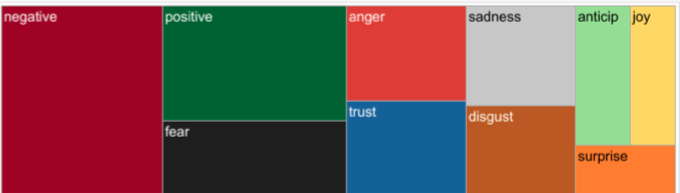

In [ ]:
library(tidytext)
#install.packages("textdata")
get_sentiments("afinn")

Do you want to download:
 Name: AFINN-111 
 URL: http://www2.imm.dtu.dk/pubdb/views/publication_details.php?id=6010 
 License: Open Database License (ODbL) v1.0 
 Size: 78 KB (cleaned 59 KB) 
 Download mechanism: https 


ERROR: ignored

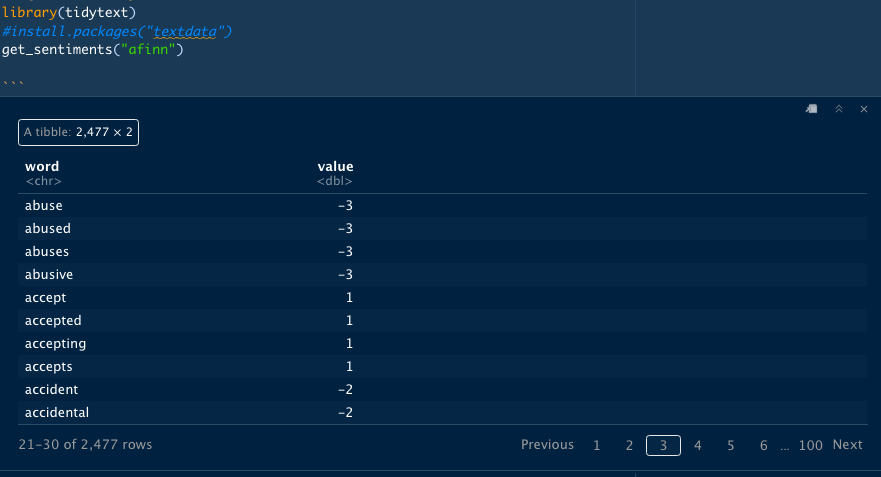

In [ ]:
library(tidytext)

load("data/afinn.rda")
afinn

Warning message in readChar(con, 5L, useBytes = TRUE):
“cannot open compressed file 'data/afinn.rda', probable reason 'No such file or directory'”


ERROR: ignored

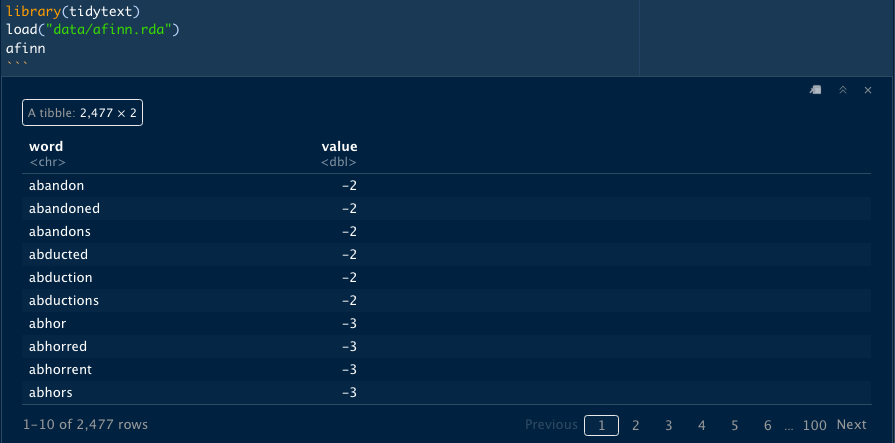

In [ ]:
get_sentiments("bing")

word,sentiment
<chr>,<chr>
2-faces,negative
abnormal,negative
abolish,negative
abominable,negative
abominably,negative
abominate,negative
abomination,negative
abort,negative
aborted,negative


In [ ]:
get_sentiments("nrc")

ERROR: ignored

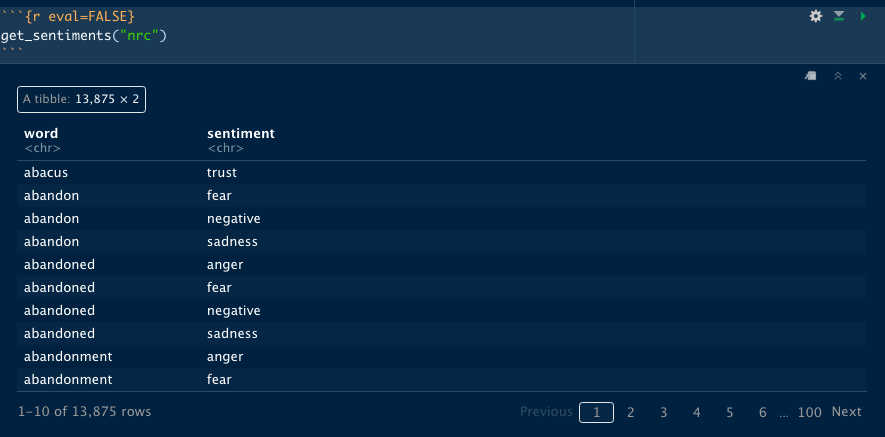

¿Cómo se elaboraron y** validaron** estos léxicos de sentimientos? Fueron construidos a través de crowdsourcing (usando, por ejemplo, **Amazon Mechanical Turk**) o por el trabajo de uno de los autores, y fueron validados usando alguna combinación de crowdsourcing nuevamente, reseñas de restaurantes o películas, o datos de Twitter.


No todas las palabras en inglés están en los léxicos porque muchas palabras en inglés son bastante neutrales. Es importante tener en cuenta que estos métodos no tienen en cuenta los calificadores antes de una palabra, como en "**no es bueno**" o "no es cierto"; un método basado en léxico como este se basa únicamente en **unigramas**. Para muchos tipos de texto, no hay secciones sostenidas de **sarcasmo** o texto negado, por lo que este no es un efecto importante. Además, podemos usar un enfoque de texto ordenado para comenzar a comprender qué tipos de palabras de negación son importantes en un texto dado.

El **tamaño** del fragmento de texto que usamos para sumar puntuaciones de sentimiento de unigrama puede tener un efecto en un análisis. Un texto del tamaño de muchos párrafos a menudo puede tener un sentimiento positivo y negativo promediado alrededor de cero, mientras que el texto del tamaño de una oración o de un párrafo a menudo funciona mejor.

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Análisis de sentimiento con inner join
</FONT>

Con datos en un **formato ordenado**, el análisis de opiniones se puede realizar como una combinación interna. Este es otro de los grandes éxitos de ver la minería de texto como una tarea ordenada de análisis de datos; Así como eliminar palabras vacías es una operación **anti-unión** **texto en negrita**, realizar análisis de opinión es una operación de unión interna.

Veamos las palabras con una puntuación de alegría del léxico de la NRC. ¿Cuáles son las palabras de alegría más comunes en** Emma**? Primero, necesitamos tomar el texto de las novelas y convertir el texto al formato ordenado usando `unnest_tokens ()`. También configuremos algunas otras columnas para realizar un seguimiento de la línea y el capítulo del libro de donde proviene cada palabra; usamos `group_by` y` mutate` para construir esas columnas.

In [ ]:
library(janeaustenr)
library(dplyr)
library(stringr)

tidy_books <- austen_books() %>%
  group_by(book) %>%
  mutate(
    linenumber = row_number(),
    chapter = cumsum(str_detect(text, 
                                regex("^chapter [\\divxlc]", 
                                      ignore_case = TRUE)))) %>%
  ungroup() %>%
  unnest_tokens(word, text)

Observe que elegimos el nombre **`word`** para la columna de salida de` unnest_tokens () `. Esta es una opción conveniente porque los léxicos de sentimiento y los conjuntos de datos de palabras vacías tienen columnas llamadas "palabra"; Por lo tanto, realizar inner join y "anti-uniones" es más fácil.

Ahora que el texto está en un formato ordenado con una palabra por fila, estamos listos para hacer el análisis de sentimientos. Primero, usemos el léxico **NRC y `filter ()`** para las palabras de alegría. A continuación, `filtremos ()` el marco de datos con el texto de los libros para las palabras de "**Emma**" y luego usemos `inner_join ()` para realizar el análisis de sentimientos. ¿Cuáles son las palabras de alegría más comunes en "Emma"? Usemos `count ()` de dplyr.


In [ ]:
nrc_joy <- get_sentiments("nrc") %>% 
  filter(sentiment == "joy")

tidy_books %>%
  filter(book == "Emma") %>%
  inner_join(nrc_joy) %>%
  count(word, sort = TRUE)

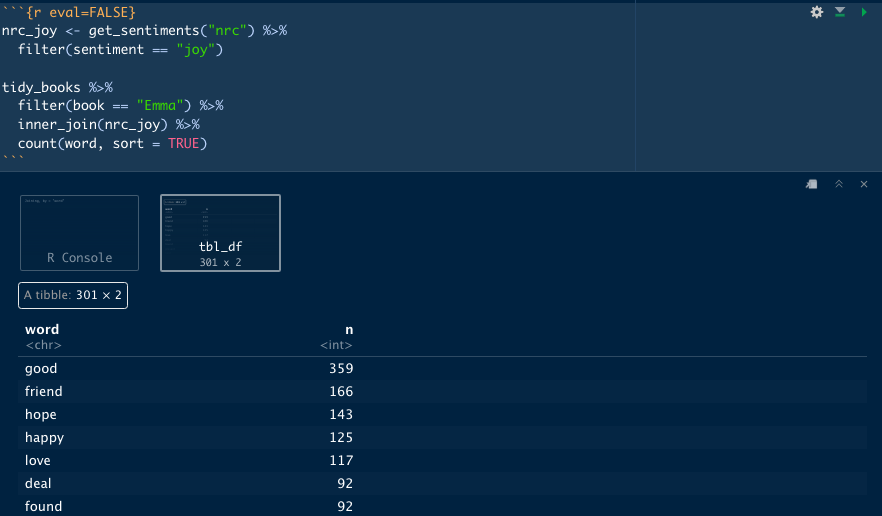

Aquí vemos palabras en su mayoría positivas y **felices sobre la esperanza, la amistad y el amor.** También vemos algunas palabras que puede que Austen no utilice con alegría ("encontrado", "regalo");

También podemos examinar cómo **cambia el sentimiento** a lo largo de cada novela. Podemos hacer esto con solo un puñado de líneas que son en su mayoría funciones dplyr. Primero, encontramos una puntuación de sentimiento para cada palabra usando el léxico de Bing y `inner_join ()`.

A continuación, contamos cuántas palabras positivas y negativas hay en las secciones definidas de cada libro. Definimos un "índice" aquí para realizar un seguimiento de dónde estamos en la narrativa; este índice (usando división de enteros) cuenta secciones de 80 líneas de texto.


In [ ]:
library(tidyr)

jane_austen_sentiment <- tidy_books %>%
  inner_join(get_sentiments("bing")) %>%
  count(book, index = linenumber %/% 80, sentiment) %>%
  pivot_wider(names_from = sentiment, values_from = n, values_fill = 0) %>% 
  mutate(sentiment = positive - negative)


Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


Joining, by = "word"



Ahora podemos trazar estas puntuaciones de sentimiento a lo largo de la trayectoria de la trama de cada novela. Observe que estamos graficando contra el `índice` en el eje x que realiza un seguimiento del tiempo narrativo en secciones de texto.

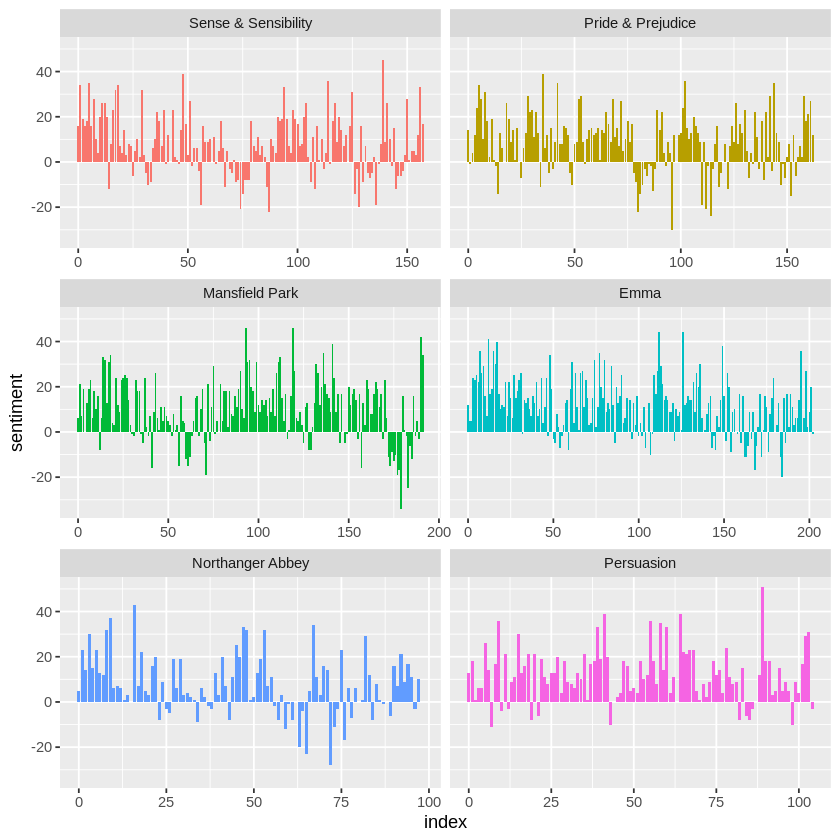

In [ ]:
library(ggplot2)

ggplot(jane_austen_sentiment, aes(index, sentiment, fill = book)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~book, ncol = 2, scales = "free_x")

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Comparando los tres diccionarios de sentimientos
</FONT>

Con varias opciones para léxicos de sentimientos, es posible que desee obtener más información sobre cuál es apropiado para sus propósitos. Usemos los tres léxicos de sentimientos y examinemos cómo cambia el sentimiento a lo largo del arco narrativo de **Orgullo y prejuicio**. Primero, usemos `filter ()` para elegir solo las palabras de la novela que nos interesa.

In [ ]:
pride_prejudice <- tidy_books %>% 
  filter(book == "Pride & Prejudice")

pride_prejudice

book,linenumber,chapter,word
<fct>,<int>,<int>,<chr>
Pride & Prejudice,1,0,pride
Pride & Prejudice,1,0,and
Pride & Prejudice,1,0,prejudice
Pride & Prejudice,3,0,by
Pride & Prejudice,3,0,jane
Pride & Prejudice,3,0,austen
Pride & Prejudice,7,1,chapter
Pride & Prejudice,7,1,1
Pride & Prejudice,10,1,it


Ahora, podemos usar `inner_join ()` para calcular el sentimiento de diferentes formas.


Recuerde que el** léxico AFINN **mide el sentimiento con una puntuación numérica entre** -5 y 5,** mientras que los otros dos léxicos clasifican las palabras de forma binaria, ya sea positiva o negativa. Para encontrar una puntuación de sentimiento en fragmentos de texto a lo largo de la novela, necesitaremos usar un patrón diferente para el léxico AFINN que para los otros dos.


Usemos nuevamente la división de enteros **(`% /%`) para definir secciones más grandes de texto que abarquen varias líneas,** y podemos usar el mismo patrón con `count ()`, `pivot_wider ()` y `mutate ()` para encuentre el sentimiento neto en cada una de estas secciones de texto.

In [ ]:
afinn <- pride_prejudice %>% 
  inner_join(get_sentiments("afinn")) %>% 
  group_by(index = linenumber %/% 80) %>% 
  summarise(sentiment = sum(value)) %>% 
  mutate(method = "AFINN")

bing_and_nrc <- bind_rows(
  pride_prejudice %>% 
    inner_join(get_sentiments("bing")) %>%
    mutate(method = "Bing et al."),
  pride_prejudice %>% 
    inner_join(get_sentiments("nrc") %>% 
                 filter(sentiment %in% c("positive", 
                                         "negative"))
    ) %>%
    mutate(method = "NRC")) %>%
  count(method, index = linenumber %/% 80, sentiment) %>%
  pivot_wider(names_from = sentiment,
              values_from = n,
              values_fill = 0) %>% 
  mutate(sentiment = positive - negative)

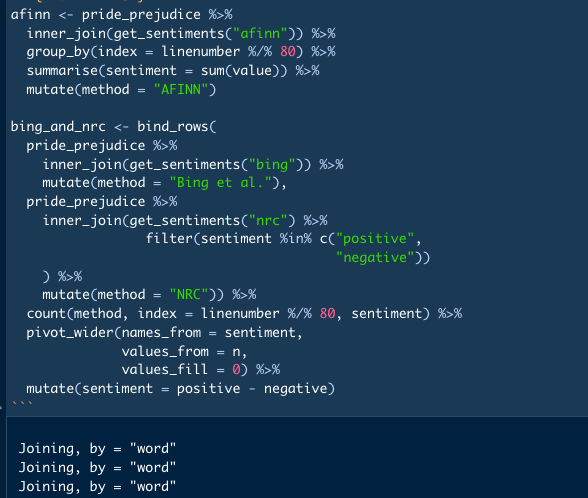

Ahora tenemos una estimación del sentimiento neto (positivo - negativo) en cada fragmento del texto novedoso para cada léxico de sentimiento. Unámoslos y visualicémoslos

Comparación de tres léxicos de sentimientos con "Orgullo y prejuicio"

In [ ]:
bind_rows(afinn, 
          bing_and_nrc) %>%
  ggplot(aes(index, sentiment, fill = method)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~method, ncol = 1, scales = "free_y")

ERROR: ignored

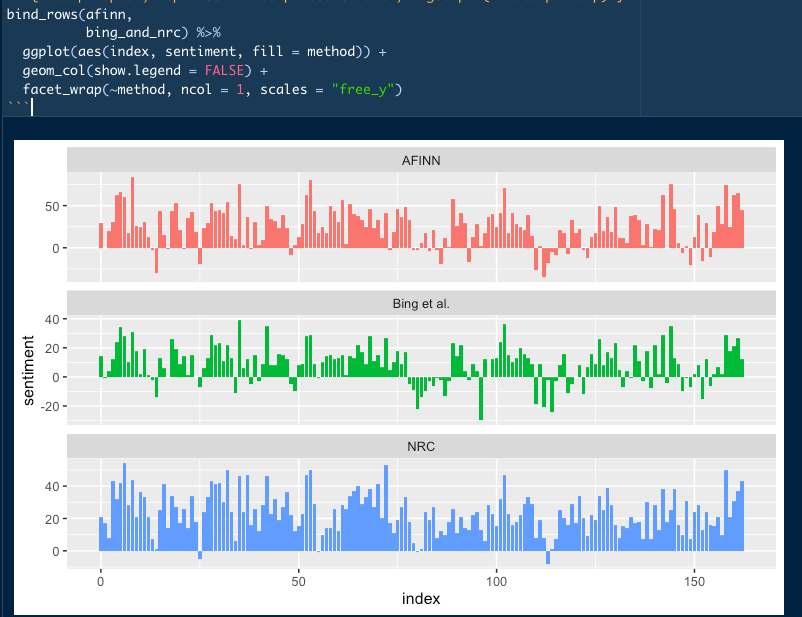

Los tres léxicos diferentes para calcular el sentimiento dan resultados que son diferentes en un sentido absoluto pero tienen trayectorias relativas similares a lo largo de la novela. **Vemos caídas y picos similares en el sentimiento en aproximadamente los mismos lugares en la novela,** pero los valores absolutos son significativamente diferentes.

 El léxico** AFINN da los valores absolutos más grandes**, con valores positivos altos. 
 
 El léxico de** Bing et al. tiene valores absolutos más bajos y parece etiquetar bloques más grandes de texto contiguo positivo o negativo**. 
 
 Los resultados de **NRC** se desplazan más alto en relación con los otros dos, etiquetando el texto de manera más positiva, pero **detecta cambios relativos similares en el texto.**
 
  Encontramos diferencias similares entre los métodos cuando miramos otras novelas; el** sentimiento de NRC** es alto, el sentimiento de **AFINN tiene más varianza**,** Bing et al. El sentimiento parece encontrar tramos más largos **de texto similar, pero los tres coinciden aproximadamente en las tendencias generales del sentimiento a través de un arco narrativo.

¿Por qué, por ejemplo, el resultado del léxico NRC tiene un sesgo tan alto en el sentimiento en comparación con el de Bing et al. ¿resultado? Veamos brevemente cuántas palabras positivas y negativas hay en estos léxicos.

In [ ]:
get_sentiments("nrc") %>% 
  filter(sentiment %in% c("positive", "negative")) %>% 
  count(sentiment)


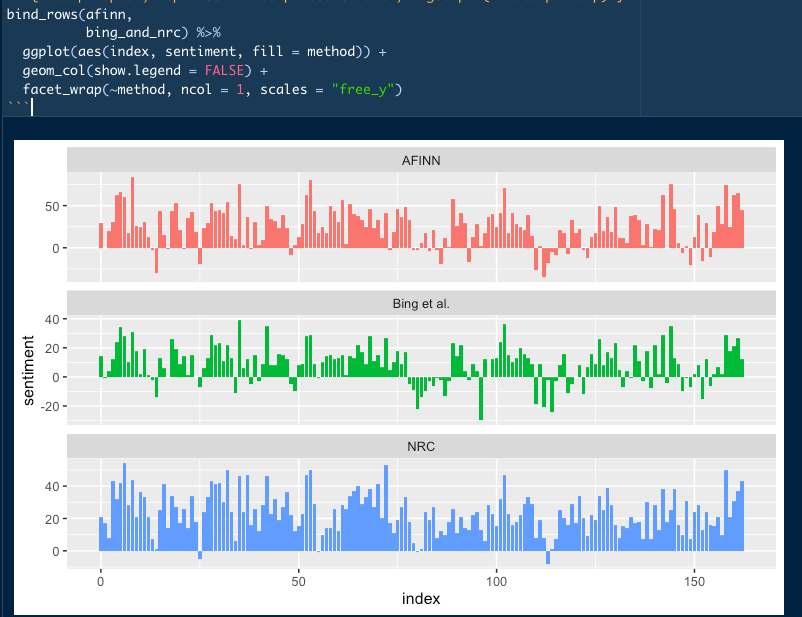

In [ ]:
nrc %>% 
  filter(sentiment %in% c("positive", "negative")) %>% 
  count(sentiment)

ERROR: ignored

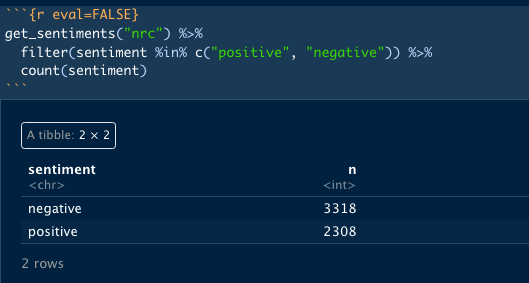

In [ ]:
get_sentiments("bing") %>% 
  count(sentiment)

sentiment,n
<chr>,<int>
negative,4781
positive,2005


Ambos léxicos tienen más palabras negativas que positivas, pero la proporción de palabras negativas a positivas es mayor en el léxico de Bing que en el léxico de la NRC. Esto contribuirá al efecto que vemos en el gráfico anterior, al igual que cualquier diferencia sistemática en las coincidencias de palabras, p. Ej. si las palabras negativas en el léxico de la NRC no coinciden con las palabras que Jane Austen usa muy bien. Cualquiera que sea la fuente de estas diferencias, vemos trayectorias relativas similares a lo largo del arco narrativo, con cambios similares en la pendiente, pero diferencias marcadas en el sentimiento absoluto de un léxico a otro. Todo este es un contexto importante a tener en cuenta al elegir un léxico de sentimientos para el análisis.

<FONT FACE="cambria" SIZE=5 COLOR="blue">
Palabras positivas y negativas más comunes
</FONT>

Una ventaja de tener el marco de datos con sentimiento y palabra es que podemos analizar el recuento de palabras que contribuyen a cada sentimiento. Al implementar `count ()` aquí con argumentos tanto de `word` como de` sentiment`, descubrimos cuánto contribuyó cada palabra a cada sentimiento.

In [ ]:
bing_word_counts <- tidy_books %>%
  inner_join(get_sentiments("bing")) %>%
  count(word, sentiment, sort = TRUE) %>%
  ungroup()

bing_word_counts

Joining, by = "word"



word,sentiment,n
<chr>,<chr>,<int>
miss,negative,1855
well,positive,1523
good,positive,1380
great,positive,981
like,positive,725
better,positive,639
enough,positive,613
happy,positive,534
love,positive,495


Esto se puede mostrar visualmente, y podemos canalizarlo directamente a ggplot2, si queremos, debido a la forma en que usamos constantemente herramientas creadas para manejar marcos de datos ordenados.

In [ ]:
bing_word_counts %>%
  group_by(sentiment) %>%
  slice_max(n, n = 10) %>% 
  ungroup() %>%
  mutate(word = reorder(word, n)) %>%
  ggplot(aes(n, word, fill = sentiment)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~sentiment, scales = "free_y") +
  labs(x = "Contribution to sentiment",
       y = NULL)

ERROR: ignored

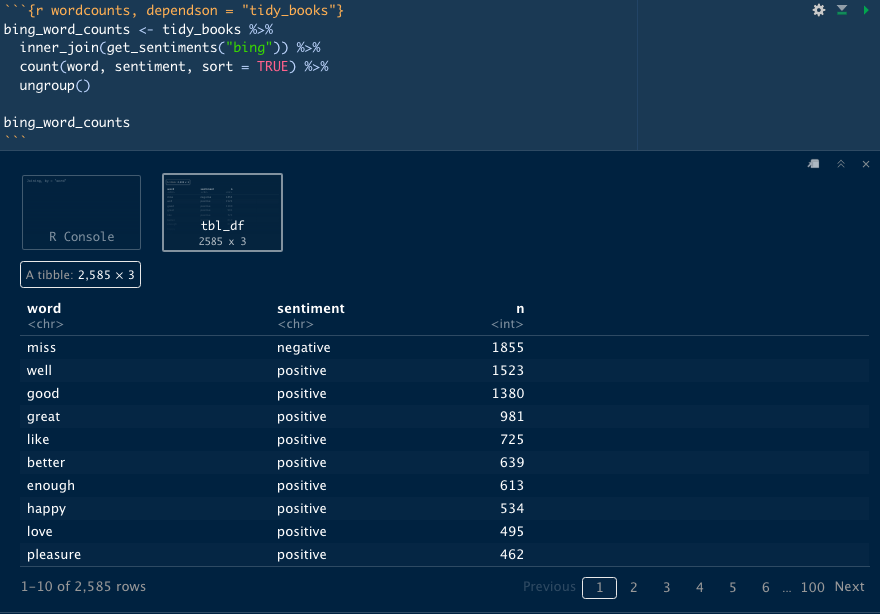

In [ ]:
bing_word_counts %>%
  group_by(sentiment) %>%
  slice_max(n, n = 10) %>% 
  ungroup() %>%
  mutate(word = reorder(word, n)) %>%
  ggplot(aes(n, word, fill = sentiment)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~sentiment, scales = "free_y") +
  labs(x = "Contribution to sentiment",
       y = NULL)

ERROR: ignored

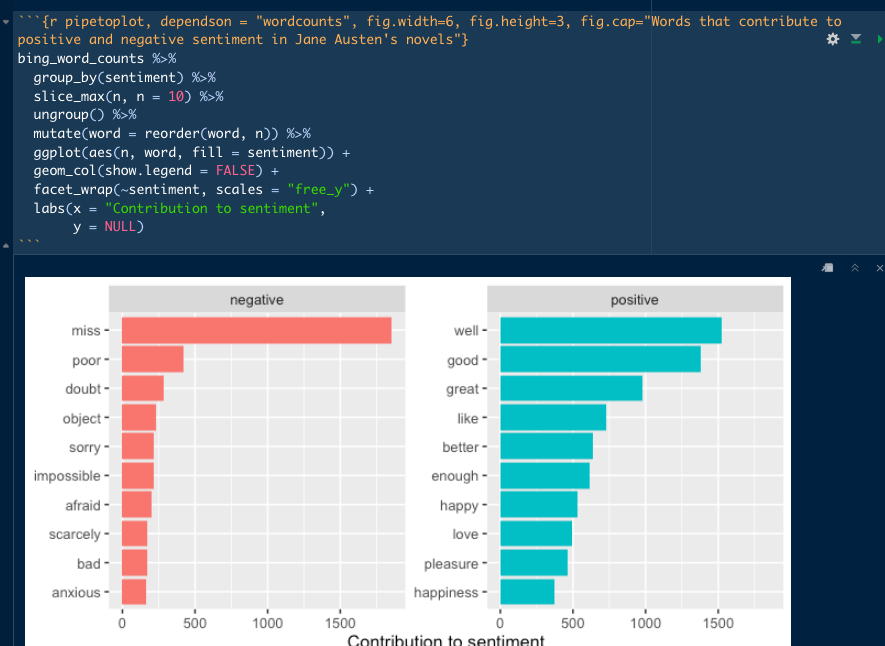

La figura nos permite detectar una anomalía en el análisis de sentimientos; la palabra "señorita" está codificada como negativa, pero se utiliza como título para mujeres jóvenes solteras en las obras de Jane Austen. Si fuera apropiado para nuestros propósitos, podríamos agregar fácilmente "fallar" a una lista personalizada de palabras vacías usando `bind_rows ()`. Podríamos implementar eso con una estrategia como esta.

<FONT FACE="cambria" SIZE=6 COLOR="red">
Nube de palabras </FONT>

Hemos visto que este enfoque de minería de texto ordenado funciona bien con ggplot2, pero tener nuestros datos en un formato ordenado también es útil para otros gráficos.

Por ejemplo, considere el paquete wordcloud, que usa gráficos base R. Veamos las palabras más comunes en las obras de Jane Austen en su conjunto nuevamente, pero esta vez como una nube de palabras en la siguiente figura.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Joining, by = "word"



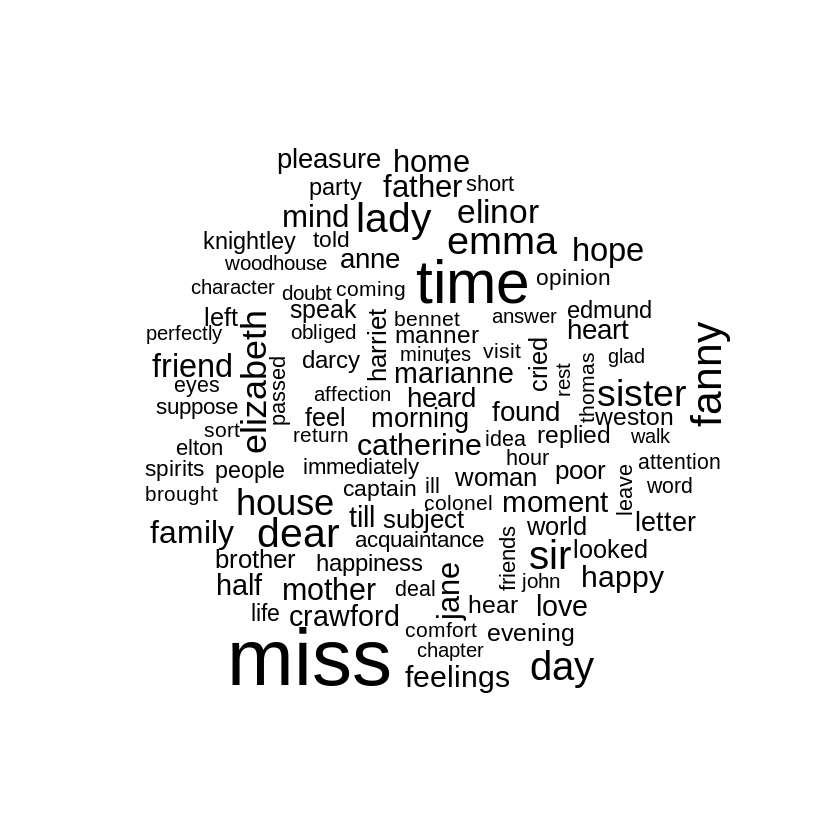

In [ ]:
install.packages("wordcloud")
library(wordcloud)

tidy_books %>%
  anti_join(stop_words) %>%
  count(word) %>%
  with(wordcloud(word, n, max.words = 100))

En otras funciones, como `compare.cloud ()`, es posible que necesite convertir el marco de datos en una matriz con `acast ()` de reshape2. Hagamos el análisis de sentimiento para etiquetar palabras positivas y negativas usando una combinación interna, luego busquemos las palabras positivas y negativas más comunes. Hasta el paso en el que necesitamos enviar los datos a `compare.cloud ()`, todo esto se puede hacer con joins, piping y dplyr porque nuestros datos están en formato ordenado.

Joining, by = "word"



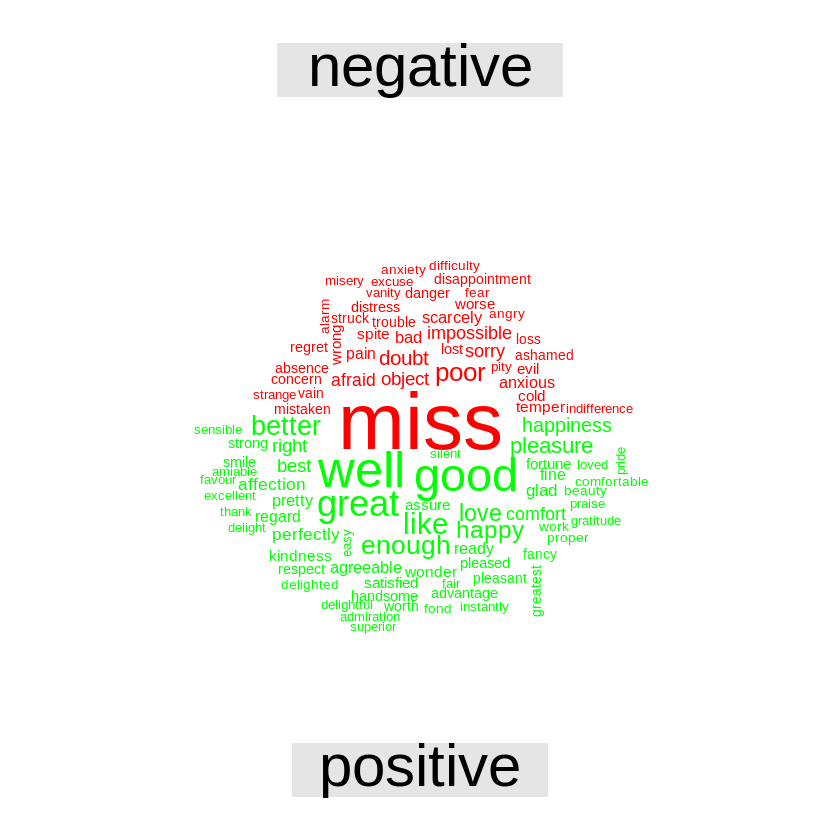

In [ ]:
library(reshape2)

tidy_books %>%
  inner_join(get_sentiments("bing")) %>%
  count(word, sentiment, sort = TRUE) %>%
  acast(word ~ sentiment, value.var = "n", fill = 0) %>%
  comparison.cloud(colors = c("red", "green"),
                   max.words = 100)

<FONT FACE="cambria" SIZE=6 COLOR="blue">
Función 'tf_idf'
</FONT>

*La* estadística 'tf_idf' se usa para medir la importancia de una palabra en un documento dentro de una colección de documentos, por ejemplo, para una novela en una colección de novelas o para un sitio web en una colección de sitios web.

Aunque hay palabras que se utilizan mucho dentro de una novela que no pueden tener mucha importancia como "de", "y", "es", etc. Estas palabras usualmente tienen una frecuencia muy alta y a su vez no ser relevantes para el fin de un estudio. Por esta razón con "idf: inverse document frequency" se buscan aquellas palabras que no se utilizan mucho dentro de un documento pero que pueden ser muy importantes para el estudio del mismo.


In [ ]:
book_words <- austen_books() %>%
  unnest_tokens(word, text) %>%
  count(book, word, sort = TRUE)

total_words <- book_words %>% 
  group_by(book) %>% 
  summarize(total = sum(n))

book_words <- left_join(book_words, total_words)

book_words

Joining, by = "book"



book,word,n,total
<fct>,<chr>,<int>,<int>
Mansfield Park,the,6206,160460
Mansfield Park,to,5475,160460
Mansfield Park,and,5438,160460
Emma,to,5239,160996
Emma,the,5201,160996
Emma,and,4896,160996
Mansfield Park,of,4778,160460
Pride & Prejudice,the,4331,122204
Emma,of,4291,160996


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

Warning message:
“Removed 896 rows containing non-finite values (stat_bin).”
Warning message:
“Removed 6 rows containing missing values (geom_bar).”


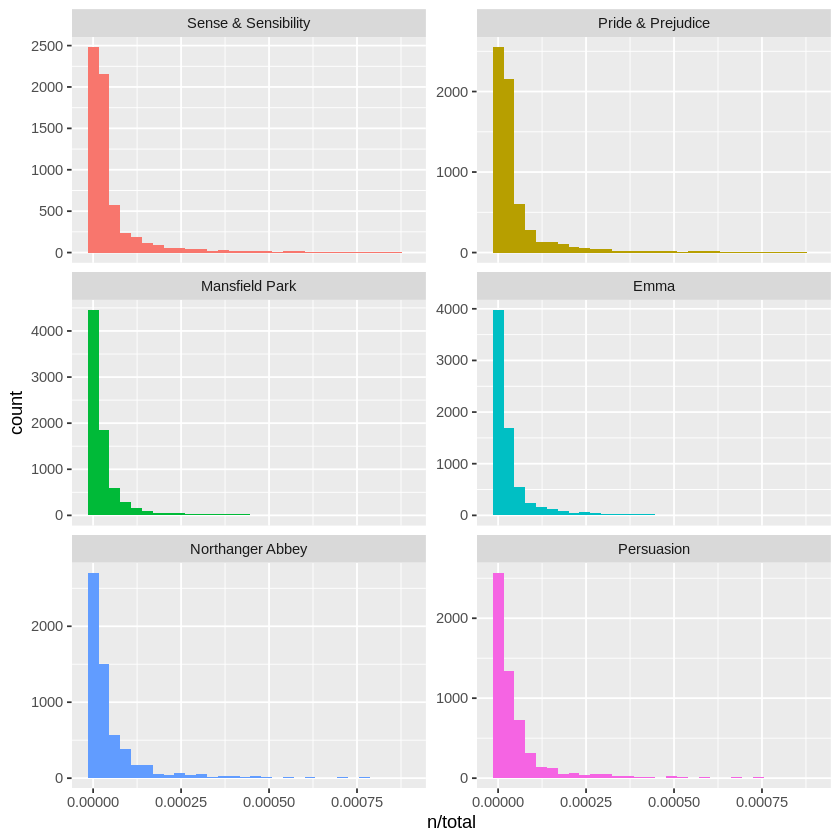

In [ ]:
ggplot(book_words, aes(n/total, fill = book)) +
  geom_histogram(show.legend = FALSE) +
  xlim(NA, 0.0009) +
  facet_wrap(~book, ncol = 2, scales = "free_y")

Frecuencia de cada palabra: 

In [ ]:
book_tf_idf <- book_words %>%
  bind_tf_idf(word, book, n)

book_tf_idf

book,word,n,total,tf,idf,tf_idf
<fct>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
Mansfield Park,the,6206,160460,0.03867631,0,0
Mansfield Park,to,5475,160460,0.03412065,0,0
Mansfield Park,and,5438,160460,0.03389007,0,0
Emma,to,5239,160996,0.03254118,0,0
Emma,the,5201,160996,0.03230515,0,0
Emma,and,4896,160996,0.03041069,0,0
Mansfield Park,of,4778,160460,0.02977689,0,0
Pride & Prejudice,the,4331,122204,0.03544074,0,0
Emma,of,4291,160996,0.02665284,0,0


Haciendo uso de la funcion 'tf_idf' tenemos:

In [ ]:
book_tf_idf %>%
  select(-total) %>%
  arrange(desc(tf_idf))

book,word,n,tf,idf,tf_idf
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Sense & Sensibility,elinor,623,0.005193528,1.7917595,0.009305552
Sense & Sensibility,marianne,492,0.004101470,1.7917595,0.007348847
Mansfield Park,crawford,493,0.003072417,1.7917595,0.005505032
Pride & Prejudice,darcy,373,0.003052273,1.7917595,0.005468939
Persuasion,elliot,254,0.003036171,1.7917595,0.005440088
Emma,emma,786,0.004882109,1.0986123,0.005363545
Northanger Abbey,tilney,196,0.002519928,1.7917595,0.004515105
Emma,weston,389,0.002416209,1.7917595,0.004329266
Pride & Prejudice,bennet,294,0.002405813,1.7917595,0.004310639


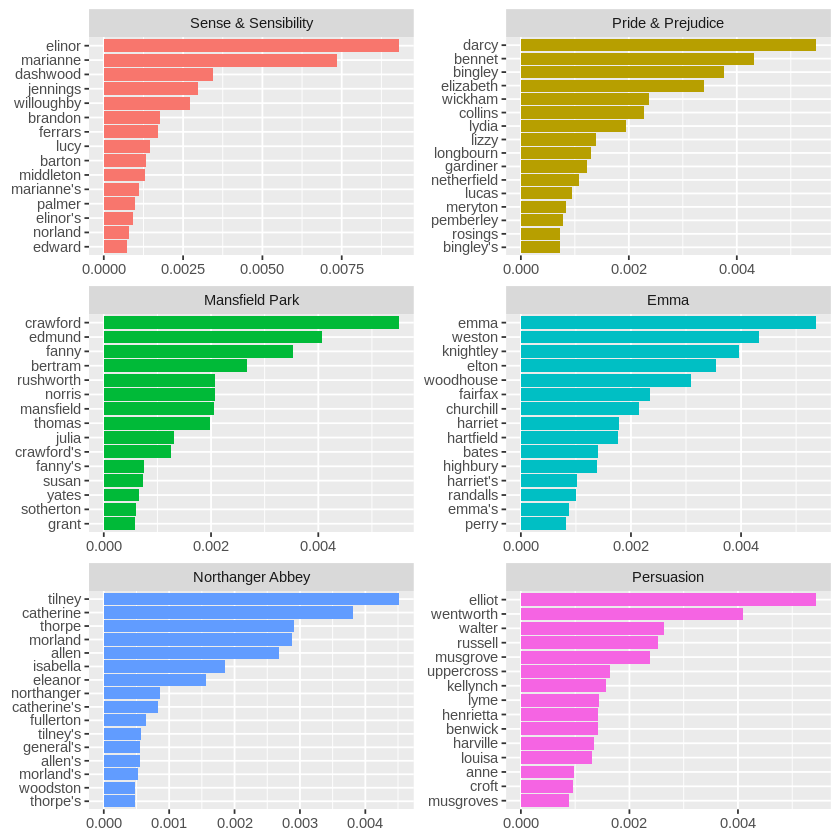

In [ ]:
library(forcats)
book_tf_idf %>%
  group_by(book) %>%
  slice_max(tf_idf, n = 15) %>%
  ungroup() %>%
  ggplot(aes(tf_idf, fct_reorder(word, tf_idf), fill = book)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~book, ncol = 2, scales = "free") +
  labs(x = NULL, y = NULL)


<FONT FACE="cambria" SIZE=5 COLOR="red">
Ejemplo con textos de Física: </FONT>

En este ejemplo haremos uso del Proyecto Gutenberg y de cuatro libros: 



1.   Discourse on Floating Bodies by Galileo Galilei
2.   Treatise on Light by Christiaan Huygens
3.   Experiments with Alternate Currents of High Potential and High Frequency by Nikola Tesla
4.   Relativity: The Special and General Theory by Albert Einstein.



In [ ]:
install.packages('gutenbergr')
library(gutenbergr)
physics <- gutenberg_download(c(37729, 14725, 13476, 30155), 
                              meta_fields = "author")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘triebeard’, ‘urltools’, ‘lazyeval’


Determining mirror for Project Gutenberg from http://www.gutenberg.org/robot/harvest

Using mirror http://aleph.gutenberg.org



In [ ]:
physics_words <- physics %>%
  unnest_tokens(word, text) %>%
  count(author, word, sort = TRUE)

physics_words

author,word,n
<chr>,<chr>,<int>
"Galilei, Galileo",the,3760
"Tesla, Nikola",the,3604
"Huygens, Christiaan",the,3553
"Einstein, Albert",the,2993
"Galilei, Galileo",of,2049
"Einstein, Albert",of,2028
"Tesla, Nikola",of,1737
"Huygens, Christiaan",of,1708
"Huygens, Christiaan",to,1207


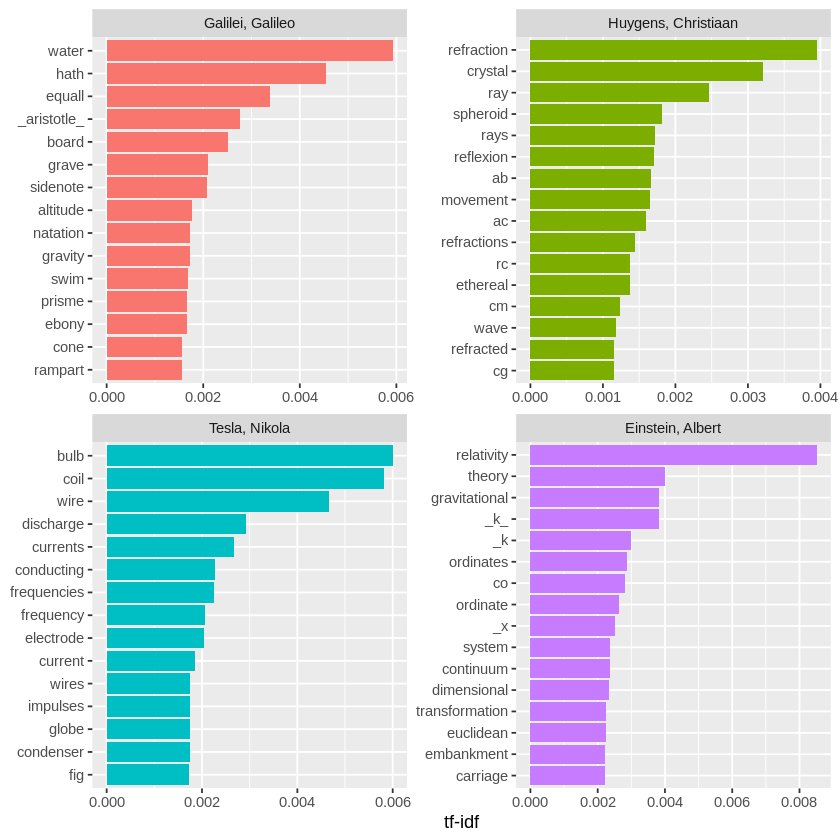

In [ ]:
plot_physics <- physics_words %>%
  bind_tf_idf(word, author, n) %>%
  mutate(author = factor(author, levels = c("Galilei, Galileo",
                                            "Huygens, Christiaan", 
                                            "Tesla, Nikola",
                                            "Einstein, Albert")))

plot_physics %>% 
  group_by(author) %>% 
  slice_max(tf_idf, n = 15) %>% 
  ungroup() %>%
  mutate(word = reorder(word, tf_idf)) %>%
  ggplot(aes(tf_idf, word, fill = author)) +
  geom_col(show.legend = FALSE) +
  labs(x = "tf-idf", y = NULL) +
  facet_wrap(~author, ncol = 2, scales = "free")

In [ ]:
physics %>% 
  filter(str_detect(text, "_k_")) %>% 
  select(text)

text
<chr>
surface AB at the points AK_k_B. Then instead of the hemispherical
would needs be that from all the other points K_k_B there should
"necessarily be equal to CD, because C_k_ is equal to CK, and C_g_ to"
"the crystal at K_k_, all the points of the wave CO_oc_ will have"
"O_o_ has reached K_k_. Which is easy to comprehend, since, of these"
"CO_oc_ in the crystal, when O_o_ has arrived at K_k_, because it forms"
ρ is the average density of the matter and _k_ is a constant connected


In [ ]:
physics %>% 
  filter(str_detect(text, "RC")) %>% 
  select(text)

text
<chr>
"line RC, parallel and equal to AB, to be a portion of a wave of light,"
"represents the partial wave coming from the point A, after the wave RC"
"be the propagation of the wave RC which fell on AB, and would be the"
"transparent body; seeing that the wave RC, having come to the aperture"
incident rays. Let there be such a ray RC falling upon the surface
"CK. Make CO perpendicular to RC, and across the angle KCO adjust OK,"
"the required refraction of the ray RC. The demonstration of this is,"
explaining ordinary refraction. For the refraction of the ray RC is
"29. Now as we have found CI the refraction of the ray RC, similarly"


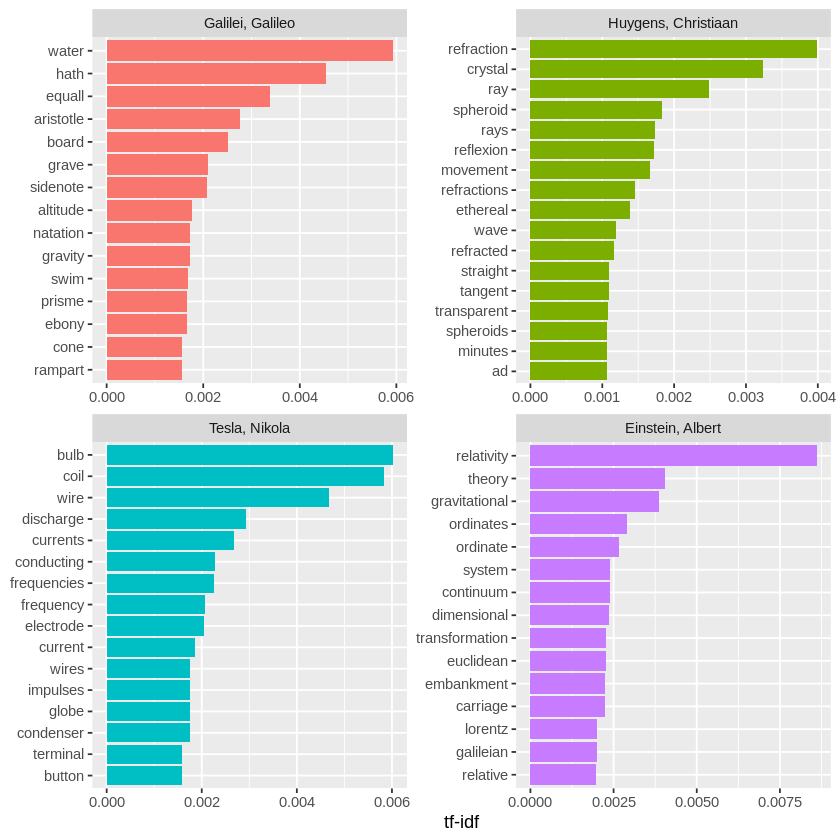

In [ ]:
mystopwords <- tibble(word = c("eq", "co", "rc", "ac", "ak", "bn", 
                                   "fig", "file", "cg", "cb", "cm",
                               "ab", "_k", "_k_", "_x"))

physics_words <- anti_join(physics_words, mystopwords, 
                           by = "word")

plot_physics <- physics_words %>%
  bind_tf_idf(word, author, n) %>%
  mutate(word = str_remove_all(word, "_")) %>%
  group_by(author) %>% 
  slice_max(tf_idf, n = 15) %>%
  ungroup() %>%
  mutate(word = reorder_within(word, tf_idf, author)) %>%
  mutate(author = factor(author, levels = c("Galilei, Galileo",
                                            "Huygens, Christiaan",
                                            "Tesla, Nikola",
                                            "Einstein, Albert")))

ggplot(plot_physics, aes(word, tf_idf, fill = author)) +
  geom_col(show.legend = FALSE) +
  labs(x = NULL, y = "tf-idf") +
  facet_wrap(~author, ncol = 2, scales = "free") +
  coord_flip() +
  scale_x_reordered()

<FONT FACE="cambria" SIZE=6 COLOR="blue">
N-gramas
</FONT>

Los n-gramas son conjuntos de 'n' cantidad de palabras que juntas pueden ser utilizadas para el estudio de un texto o una colección de textos.

In [ ]:
austen_bigrams <- austen_books() %>%
  unnest_tokens(bigram, text, token = "ngrams", n = 2)

austen_bigrams

book,bigram
<fct>,<chr>
Sense & Sensibility,sense and
Sense & Sensibility,and sensibility
Sense & Sensibility,NA
Sense & Sensibility,by jane
Sense & Sensibility,jane austen
Sense & Sensibility,NA
Sense & Sensibility,NA
Sense & Sensibility,NA
Sense & Sensibility,NA


In [ ]:
austen_bigrams %>%
  count(bigram, sort = TRUE)

bigram,n
<chr>,<int>
NA,12242
of the,2853
to be,2670
in the,2221
it was,1691
i am,1485
she had,1405
of her,1363
to the,1315


Bigramas más comunes

In [ ]:
library(tidyr)

bigrams_separated <- austen_bigrams %>%
  separate(bigram, c("word1", "word2"), sep = " ")

bigrams_filtered <- bigrams_separated %>%
  filter(!word1 %in% stop_words$word) %>%
  filter(!word2 %in% stop_words$word)

# new bigram counts:
bigram_counts <- bigrams_filtered %>% 
  count(word1, word2, sort = TRUE)

bigram_counts

word1,word2,n
<chr>,<chr>,<int>
NA,NA,12242
sir,thomas,266
miss,crawford,196
captain,wentworth,143
miss,woodhouse,143
frank,churchill,114
lady,russell,110
sir,walter,108
lady,bertram,101


Bigramas sin 'stop words'

In [ ]:
bigrams_united <- bigrams_filtered %>%
  unite(bigram, word1, word2, sep = " ")

bigrams_united

book,bigram
<fct>,<chr>
Sense & Sensibility,NA NA
Sense & Sensibility,jane austen
Sense & Sensibility,NA NA
Sense & Sensibility,NA NA
Sense & Sensibility,NA NA
Sense & Sensibility,NA NA
Sense & Sensibility,NA NA
Sense & Sensibility,NA NA
Sense & Sensibility,chapter 1


Trigramas más comunes

In [ ]:
austen_books() %>%
  unnest_tokens(trigram, text, token = "ngrams", n = 3) %>%
  separate(trigram, c("word1", "word2", "word3"), sep = " ") %>%
  filter(!word1 %in% stop_words$word,
         !word2 %in% stop_words$word,
         !word3 %in% stop_words$word) %>%
  count(word1, word2, word3, sort = TRUE)

word1,word2,word3,n
<chr>,<chr>,<chr>,<int>
NA,NA,NA,13260
dear,miss,woodhouse,20
miss,de,bourgh,17
lady,catherine,de,11
poor,miss,taylor,11
sir,walter,elliot,10
catherine,de,bourgh,9
dear,sir,thomas,8
replied,miss,crawford,7


<FONT FACE="cambria" SIZE=5 COLOR="red">
Analizando bigramas </FONT>

Bigramas de las calles más nombradas en los libros

In [ ]:
bigrams_filtered %>%
  filter(word2 == "street") %>%
  count(book, word1, sort = TRUE)

book,word1,n
<fct>,<chr>,<int>
Sense & Sensibility,harley,16
Sense & Sensibility,berkeley,15
Northanger Abbey,milsom,10
Northanger Abbey,pulteney,10
Mansfield Park,wimpole,9
Pride & Prejudice,gracechurch,8
Persuasion,milsom,5
Sense & Sensibility,bond,4
Sense & Sensibility,conduit,4


Función `tf_idf' aplicada a los bigramas

In [ ]:
bigram_tf_idf <- bigrams_united %>%
  count(book, bigram) %>%
  bind_tf_idf(bigram, book, n) %>%
  arrange(desc(tf_idf))

bigram_tf_idf

book,bigram,n,tf,idf,tf_idf
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Mansfield Park,sir thomas,266,0.024423836,1.791759,0.043761640
Persuasion,captain wentworth,143,0.023214286,1.791759,0.041594416
Mansfield Park,miss crawford,196,0.017996511,1.791759,0.032245419
Persuasion,lady russell,110,0.017857143,1.791759,0.031995705
Persuasion,sir walter,108,0.017532468,1.791759,0.031413965
Emma,miss woodhouse,143,0.012881722,1.791759,0.023080948
Northanger Abbey,miss tilney,74,0.012782864,1.791759,0.022903818
Sense & Sensibility,colonel brandon,96,0.011457214,1.791759,0.020528573
Sense & Sensibility,sir john,94,0.011218522,1.791759,0.020100894


<FONT FACE="cambria" SIZE=6 COLOR="blue">
Visualización de bigramas con redes
</FONT>


In [ ]:
install.packages('igraph')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(igraph)

# original counts
bigram_counts



word1,word2,n
<chr>,<chr>,<int>
NA,NA,12242
sir,thomas,266
miss,crawford,196
captain,wentworth,143
miss,woodhouse,143
frank,churchill,114
lady,russell,110
sir,walter,108
lady,bertram,101


In [ ]:
bigram_graph <- bigram_counts %>%
  filter(n > 20) %>%
  graph_from_data_frame()

bigram_graph

Warning message in graph_from_data_frame(.):
“In `d' `NA' elements were replaced with string "NA"”


IGRAPH c15443e DN-- 86 71 -- 
+ attr: name (v/c), n (e/n)
+ edges from c15443e (vertex names):
 [1] NA      ->NA         sir     ->thomas     miss    ->crawford  
 [4] captain ->wentworth  miss    ->woodhouse  frank   ->churchill 
 [7] lady    ->russell    sir     ->walter     lady    ->bertram   
[10] miss    ->fairfax    colonel ->brandon    sir     ->john      
[13] miss    ->bates      jane    ->fairfax    lady    ->catherine 
[16] lady    ->middleton  miss    ->tilney     miss    ->bingley   
[19] thousand->pounds     miss    ->dashwood   dear    ->miss      
[22] miss    ->bennet     miss    ->morland    captain ->benwick   
+ ... omitted several edges

In [ ]:
install.packages('ggraph')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘RcppEigen’, ‘gridExtra’, ‘RcppArmadillo’, ‘ggforce’, ‘ggrepel’, ‘viridis’, ‘tidygraph’, ‘graphlayouts’




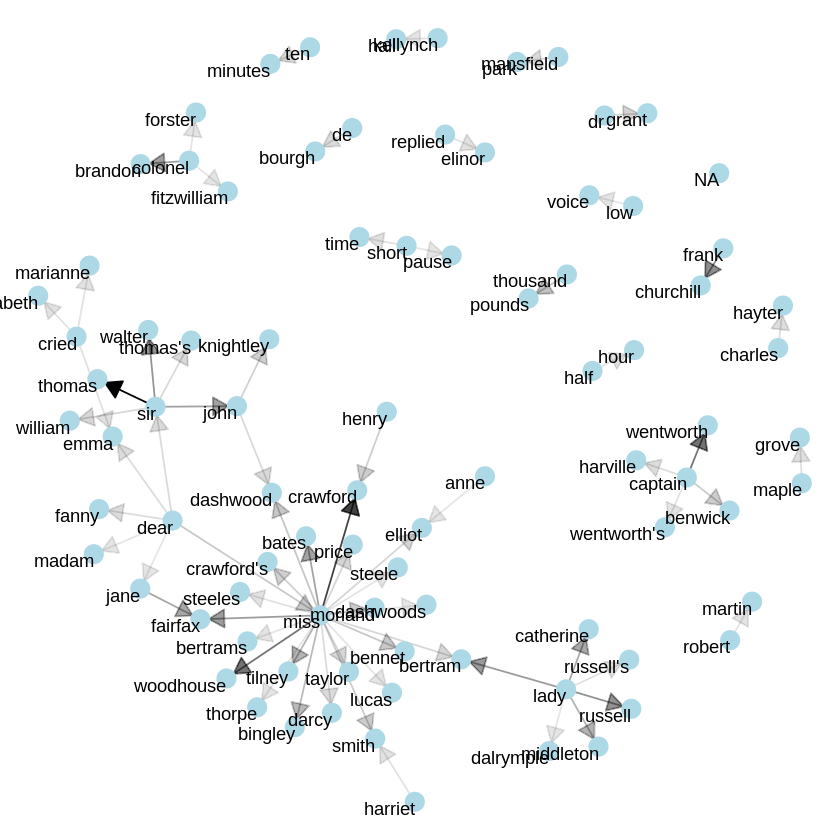

In [ ]:
library(ggraph)
set.seed(2021)

a <- grid::arrow(type = "closed", length = unit(.15, "inches"))

ggraph(bigram_graph, layout = "fr") +
  geom_edge_link(aes(edge_alpha = n), show.legend = FALSE,
                 arrow = a, end_cap = circle(.07, 'inches')) +
  geom_node_point(color = "lightblue", size = 5) +
  geom_node_text(aes(label = name), vjust = 1, hjust = 1) +
  theme_void()

Funcion de R para visualizar bigramas en otros textos

In [ ]:
count_bigrams <- function(dataset) {
  dataset %>%
    unnest_tokens(bigram, text, token = "ngrams", n = 2) %>%
    separate(bigram, c("word1", "word2"), sep = " ") %>%
    filter(!word1 %in% stop_words$word,
           !word2 %in% stop_words$word) %>%
    count(word1, word2, sort = TRUE)
}

visualize_bigrams <- function(bigrams) {
  set.seed(2021)
  a <- grid::arrow(type = "closed", length = unit(.15, "inches"))
  
  bigrams %>%
    graph_from_data_frame() %>%
    ggraph(layout = "fr") +
    geom_edge_link(aes(edge_alpha = n), show.legend = FALSE, arrow = a) +
    geom_node_point(color = "lightblue", size = 5) +
    geom_node_text(aes(label = name), vjust = 1, hjust = 1) +
    theme_void()
}

Usando la funcion anterior visualizamos los bigramas más importantes de "La version de la Biblia por King James" que se encuentra en el Proyecto Guntenberg

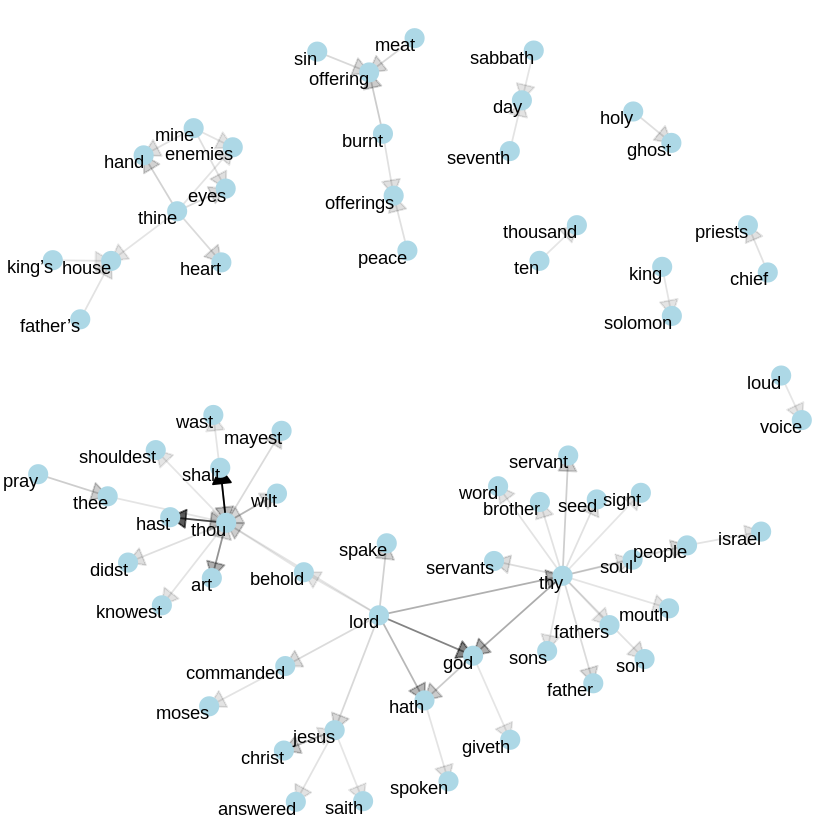

In [ ]:
library(gutenbergr)
kjv <- gutenberg_download(10)
kjv_bigrams <- kjv %>%
  count_bigrams()

# filter out rare combinations, as well as digits
kjv_bigrams %>%
  filter(n > 40,
         !str_detect(word1, "\\d"),
         !str_detect(word2, "\\d")) %>%
  visualize_bigrams()